In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

2026-04-07 18:29:52.523105: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
TRAIN_FILE = "./raw_data/data-1774627968260.csv"
VAL_FILE   = "./raw_data/data-1774610506409.csv"

CPU_MIN_THRESHOLD = 0.01
CPU_LIMIT         = 2.0    # ліміт пода при зборі (2000m) → cpu/CPU_LIMIT ∈ [0,1]
EPS               = 1e-6

# Фіксована архітектура
LAYER_SIZE    = 64
DROPOUT_RATE  = 0.35
L2_REG        = 1e-4
LEARNING_RATE = 1e-4
BATCH_SIZE    = 32
QUANTILE      = 0.85   # quantile loss — вбудований safety buffer

# Cross-validation
N_SPLITS   = 3
MAX_EPOCHS = 100
PATIENCE   = 15

# ── Простір пошуку ────────────────────────────────────────────
WINDOW_SIZES      = [6, 8, 10, 15, 20]     # 30с / 40с / 50с / 75с / 100с
FORECAST_HORIZONS = [4, 6, 9, 12]              # 30с / 45с / 60с
# velocity        — pct_change(cpu) + pct_change(rps)              (2 фічі)
# velocity+cpu_level — + поточна cpu utilization [0,1]             (3 фічі)
FEATURE_MODES     = ['velocity', 'velocity+cpu_level']

total_runs = len(WINDOW_SIZES) * len(FORECAST_HORIZONS) * len(FEATURE_MODES)
print(f"Комбінацій: {total_runs} × {N_SPLITS} folds = {total_runs * N_SPLITS} тренувань")


Комбінацій: 40 × 3 folds = 120 тренувань


In [3]:
def load_locust(path):
    df = pd.read_csv(path, parse_dates=['ts'])
    df = df.sort_values('ts').reset_index(drop=True)
    df = df.rename(columns={'input_cpu': 'cpu', 'input_ram': 'ram', 'input_rps': 'rps'})
    df = df[['cpu', 'rps']].dropna()
    df = df[df['cpu'] > CPU_MIN_THRESHOLD].reset_index(drop=True)
    df['cpu'] = df['cpu'] / CPU_LIMIT   # utilization [0, 1]
    return df

df_train = load_locust(TRAIN_FILE)
df_val   = load_locust(VAL_FILE)
print(f"Train: {len(df_train)} рядків")
print(f"Val:   {len(df_val)} рядків (held-out)")
print(f"CPU utilization range — train: [{df_train['cpu'].min():.3f}, {df_train['cpu'].max():.3f}]")


Train: 1717 рядків
Val:   358 рядків (held-out)
CPU utilization range — train: [0.005, 0.829]


In [4]:
import tensorflow.keras.backend as K

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return K.mean(K.maximum(q * e, (q - 1) * e))
    loss.__name__ = f'quantile_loss_q{int(q*100)}'
    return loss


def transform_data(df, forecast_horizon, feature_mode):
    """
    Колонки виходу:
      velocity:           [cpu_step, rps_step,            target]  (n=2)
      velocity+cpu_level: [cpu_step, rps_step, cpu_level, target]  (n=3)

    target = max(cpu_utilization over next horizon steps) ∈ [0, 1]
    """
    out = pd.DataFrame()
    out['cpu_step'] = (df['cpu'] - df['cpu'].shift(1)) / (df['cpu'].shift(1) + EPS)
    out['rps_step'] = (df['rps'] - df['rps'].shift(1)) / (df['rps'].shift(1) + EPS)

    if feature_mode == 'velocity+cpu_level':
        out['cpu_level'] = df['cpu'].values   # utilization [0,1], без pct_change

    # Таргет: max utilization за горизонт — абсолютний, ∈ [0, 1]
    out['target'] = df['cpu'].rolling(window=forecast_horizon).max().shift(-forecast_horizon)

    return out.dropna().values


def n_feat(feature_mode):
    return 2 if feature_mode == 'velocity' else 3


def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size + 1):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size - 1])
    return np.array(Xs), np.array(ys)


def build_model(window_size, n_features):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        GRU(
            LAYER_SIZE,
            kernel_regularizer=l2(L2_REG),
            recurrent_regularizer=l2(L2_REG),
        ),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid'),   # sigmoid: вихід гарантовано ∈ (0, 1)
    ])
    model.compile(
        optimizer=Adam(LEARNING_RATE, clipnorm=1.0),
        loss=quantile_loss(QUANTILE),
        metrics=['mae'],
    )
    return model


def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5),
    ]

print("Helpers defined.")


Helpers defined.


In [5]:
def cross_validate(df, window_size, forecast_horizon, feature_mode):
    """
    Walk-forward cross-validation (TimeSeriesSplit).
    Повертає (mean_val_loss, std_val_loss) по N_SPLITS фолдах.
    """
    raw = transform_data(df, forecast_horizon, feature_mode)
    nf  = n_feat(feature_mode)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_losses = []

    for train_idx, val_idx in tscv.split(raw):
        raw_tr = raw[train_idx]
        raw_vl = raw[val_idx]

        min_rows = window_size + 5
        if len(raw_tr) < min_rows or len(raw_vl) < min_rows:
            continue

        scaler_X = StandardScaler()
        X_tr_sc = scaler_X.fit_transform(raw_tr[:, :nf])
        y_tr    = raw_tr[:, nf]   # utilization [0,1] — scaler_y не потрібен
        X_vl_sc = scaler_X.transform(raw_vl[:, :nf])
        y_vl    = raw_vl[:, nf]

        X_tr, y_tr = create_sequences(X_tr_sc, y_tr.reshape(-1, 1), window_size)
        X_vl, y_vl = create_sequences(X_vl_sc, y_vl.reshape(-1, 1), window_size)

        tf.random.set_seed(42)
        model = build_model(window_size, nf)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=make_callbacks(),
            verbose=0,
        )

        best_val_loss = min(model.history.history['val_loss'])
        fold_losses.append(best_val_loss)

    if not fold_losses:
        return float('nan'), float('nan')
    return float(np.mean(fold_losses)), float(np.std(fold_losses))

print("cross_validate() defined.")


cross_validate() defined.


In [6]:
results = []
total = len(WINDOW_SIZES) * len(FORECAST_HORIZONS) * len(FEATURE_MODES)
i = 0

for ws in WINDOW_SIZES:
    for fh in FORECAST_HORIZONS:
        for fm in FEATURE_MODES:
            i += 1
            t0 = time.time()
            mean_loss, std_loss = cross_validate(df_train, ws, fh, fm)
            elapsed = time.time() - t0
            results.append({
                'window_size':      ws,
                'context_sec':      ws * 5,
                'forecast_horizon': fh,
                'horizon_sec':      fh * 5,
                'feature_mode':     fm,
                'mean_val_loss':    round(mean_loss, 4),
                'std_val_loss':     round(std_loss, 4),
            })
            print(f"[{i:2d}/{total}] ws={ws:2d}({ws*5:3d}s) fh={fh}({fh*5}s) {fm:15s} "
                  f"→ loss={mean_loss:.4f}±{std_loss:.4f}  ({elapsed:.0f}s)")

results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
print("\n── Топ-5 конфігурацій ──")
print(results_df[['window_size','horizon_sec','feature_mode','mean_val_loss','std_val_loss']].head(5).to_string(index=False))

[ 1/40] ws= 6( 30s) fh=4(20s) velocity        → loss=0.0579±0.0048  (47s)
[ 2/40] ws= 6( 30s) fh=4(20s) velocity+cpu_level → loss=0.0466±0.0049  (65s)
[ 3/40] ws= 6( 30s) fh=6(30s) velocity        → loss=0.0532±0.0054  (48s)
[ 4/40] ws= 6( 30s) fh=6(30s) velocity+cpu_level → loss=0.0492±0.0062  (49s)
[ 5/40] ws= 6( 30s) fh=9(45s) velocity        → loss=0.0439±0.0052  (44s)
[ 6/40] ws= 6( 30s) fh=9(45s) velocity+cpu_level → loss=0.0424±0.0063  (45s)
[ 7/40] ws= 6( 30s) fh=12(60s) velocity        → loss=0.0384±0.0067  (43s)
[ 8/40] ws= 6( 30s) fh=12(60s) velocity+cpu_level → loss=0.0369±0.0061  (44s)
[ 9/40] ws= 8( 40s) fh=4(20s) velocity        → loss=0.0586±0.0040  (44s)
[10/40] ws= 8( 40s) fh=4(20s) velocity+cpu_level → loss=0.0468±0.0043  (58s)
[11/40] ws= 8( 40s) fh=6(30s) velocity        → loss=0.0524±0.0051  (47s)
[12/40] ws= 8( 40s) fh=6(30s) velocity+cpu_level → loss=0.0492±0.0065  (52s)
[13/40] ws= 8( 40s) fh=9(45s) velocity        → loss=0.0440±0.0053  (49s)
[14/40] ws= 8( 40s

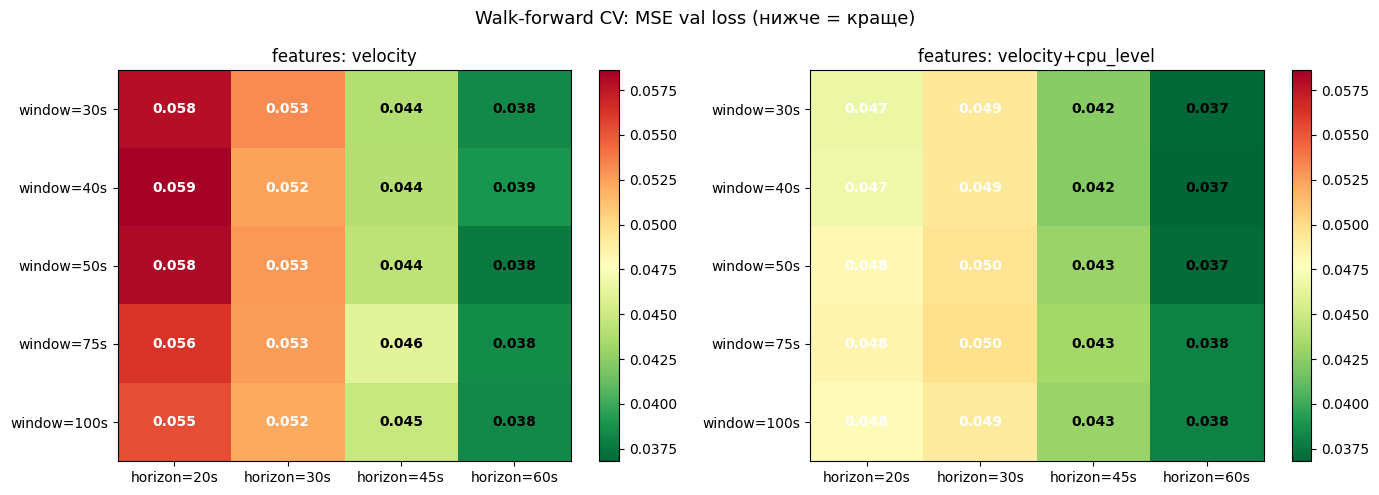

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Walk-forward CV: MSE val loss (нижче = краще)', fontsize=13)

for ax, fm in zip(axes, FEATURE_MODES):
    subset = results_df[results_df['feature_mode'] == fm]
    pivot  = subset.pivot(index='window_size', columns='forecast_horizon', values='mean_val_loss')

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=results_df['mean_val_loss'].min(),
                   vmax=results_df['mean_val_loss'].max())

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'horizon={c*5}s' for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'window={r*5}s' for r in pivot.index])
    ax.set_title(f'features: {fm}')

    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val > pivot.values.mean() else 'black')

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('hyperparam_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Фінальна оцінка найкращої конфігурації на held-out val ──
best = results_df.iloc[0]
print(f"Найкраща конфігурація:")
print(f"  window_size={best.window_size} ({best.context_sec}s)")
print(f"  forecast_horizon={best.forecast_horizon} ({best.horizon_sec}s)")
print(f"  feature_mode={best.feature_mode}")
print(f"  CV loss: {best.mean_val_loss:.4f} ± {best.std_val_loss:.4f}")

ws = int(best.window_size)
fh = int(best.forecast_horizon)
fm = best.feature_mode
nf = n_feat(fm)

raw_tr = transform_data(df_train, fh, fm)
raw_vl = transform_data(df_val,   fh, fm)

scaler_X = StandardScaler()
X_tr_sc = scaler_X.fit_transform(raw_tr[:, :nf])
y_tr    = raw_tr[:, nf]
X_vl_sc = scaler_X.transform(raw_vl[:, :nf])
y_vl    = raw_vl[:, nf]

X_tr, y_tr = create_sequences(X_tr_sc, y_tr.reshape(-1, 1), ws)
X_vl, y_vl = create_sequences(X_vl_sc, y_vl.reshape(-1, 1), ws)

tf.random.set_seed(42)
best_model = build_model(ws, nf)
history = best_model.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f"\nBest epoch: {best_epoch}")


Найкраща конфігурація:
  window_size=8 (40s)
  forecast_horizon=12 (60s)
  feature_mode=velocity+cpu_level
  CV loss: 0.0368 ± 0.0059
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1422 - mae: 0.2242 - val_loss: 0.1261 - val_mae: 0.1988 - learning_rate: 1.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1215 - mae: 0.2056 - val_loss: 0.1065 - val_mae: 0.1850 - learning_rate: 1.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0979 - mae: 0.1892 - val_loss: 0.0819 - val_mae: 0.1733 - learning_rate: 1.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0726 - mae: 0.1824 - val_loss: 0.0585 - val_mae: 0.1787 - learning_rate: 1.0000e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0519 - mae: 0.1944 - val_loss: 0.0431 - val_mae: 0.2016 - learning_rate: 1.0000e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0422 - mae: 0.2103 - val_loss: 0.0407 - val_mae: 0.2139 - learning_rate: 1.0000e

Метрики на held-out val (q=0.85, без safety factor):
  MAE:       380.5 m
  RMSE:      555.4 m
  Bias:      +360.5 m  (завищує)
  Underpred: 18.0%
  Pred util range: [0.674, 0.841]


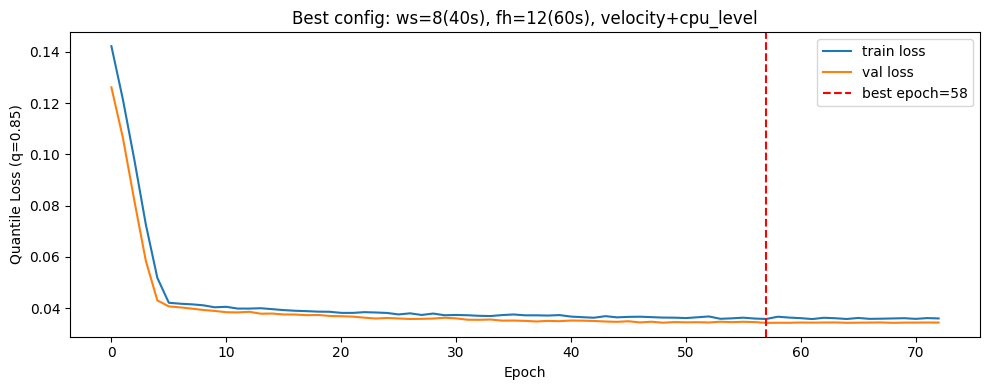

In [9]:
# Абсолютні метрики на held-out val
# Модель напряму предиктить utilization [0,1] → множимо на CPU_LIMIT для cores
X_eval_sc = scaler_X.transform(raw_vl[:, :nf])
y_eval    = raw_vl[:, nf]
X_eval, y_eval_seq = create_sequences(X_eval_sc, y_eval.reshape(-1, 1), ws)

y_pred_util = best_model.predict(X_eval, verbose=0).flatten()
y_true_util = y_eval_seq.flatten()

actual_peak_m = y_true_util * CPU_LIMIT * 1000
pred_peak_m   = y_pred_util * CPU_LIMIT * 1000

mae_m         = np.mean(np.abs(actual_peak_m - pred_peak_m))
rmse_m        = np.sqrt(np.mean((actual_peak_m - pred_peak_m) ** 2))
bias_m        = np.mean(pred_peak_m - actual_peak_m)
underpred_pct = np.mean(pred_peak_m < actual_peak_m) * 100

print(f"Метрики на held-out val (q={QUANTILE}, без safety factor):")
print(f"  MAE:       {mae_m:.1f} m")
print(f"  RMSE:      {rmse_m:.1f} m")
print(f"  Bias:      {bias_m:+.1f} m  ({'завищує' if bias_m > 0 else 'занижує'})")
print(f"  Underpred: {underpred_pct:.1f}%")
print(f"  Pred util range: [{y_pred_util.min():.3f}, {y_pred_util.max():.3f}]")

# Learning curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.axvline(best_epoch - 1, color='red', linestyle='--', label=f'best epoch={best_epoch}')
plt.xlabel('Epoch')
plt.ylabel(f'Quantile Loss (q={QUANTILE})')
plt.title(f'Best config: ws={ws}({ws*5}s), fh={fh}({fh*5}s), {fm}')
plt.legend()
plt.tight_layout()
plt.savefig('best_config_training.png', dpi=150, bbox_inches='tight')
plt.show()
